# Demo 3 — Calibrated Probabilities for Risk

### Chapter 3 of the open tabular stack: *probabilities you can size positions on*

> **In high-stakes decisions, calibration is the product.**
>
> *Trading desks size positions on P(y|x), not on the argmax.*

Setup: imbalanced binary classification (credit-card fraud, ~0.17% positives). Side-by-side reliability diagrams from HGBT vs TabICL.

| Approach | What it represents |
|---|---|
| `HGBT default` | Argmax-only baseline — strong AUC, often miscalibrated |
| `HGBT + sigmoid calibration` | Post-hoc patch via `CalibratedClassifierCV` |
| `TabICL default` | Foundation model — calibrated out of the box |

We score with **AUC**, **Brier**, **log-loss**, and **ECE** (Expected Calibration Error).

---

**Stack:** `scikit-learn`, `skrub`, `tabicl`, `skore`.

In [1]:
# pip install -U scikit-learn skrub tabicl skore pandas matplotlib
import time
import warnings
from contextlib import contextmanager

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 110

# Probabl brand palette
BLUE = "#1E22AA"
ORANGE = "#F68D2E"
GRAY = "#94A3B8"
BLUE_LIGHT = "#E8E8F5"
ORANGE_LIGHT = "#FEF0E0"
DARK = "#1A1A2E"

@contextmanager
def stopwatch(label):
    t0 = time.perf_counter()
    yield (lambda: time.perf_counter() - t0)
    elapsed = time.perf_counter() - t0
    print(f"  [{label}] wall-clock: {elapsed:.1f}s")

## 1. Imbalanced fraud-flavored data

The public **credit-card fraud** dataset on OpenML: ~284k transactions, ~0.17% labelled
fraud. We sub-sample to keep the imbalance visible while making TabICL tractable on CPU:
**all positives + 5,000 random negatives** ≈ 5.5k rows. The minority rate is the whole point —
it's what makes the default classifier's argmax useless and miscalibration costly.

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

data = fetch_openml("creditcard", version=1, as_frame=True)
X_full = data.data
y_full = data.target.astype(int)  # already 0/1

rng = np.random.RandomState(42)
pos_idx = np.flatnonzero(y_full.values == 1)
neg_idx = np.flatnonzero(y_full.values == 0)
neg_sample = rng.choice(neg_idx, size=5000, replace=False)
keep = np.sort(np.concatenate([pos_idx, neg_sample]))

X = X_full.iloc[keep].reset_index(drop=True)
y = y_full.iloc[keep].reset_index(drop=True)

print(f"Sub-sampled shape: {X.shape}")
print(f"Positive rate: {y.mean():.4f}  (n_pos={int(y.sum())}, n_neg={int((1 - y).sum())})")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}  ·  Test: {X_test.shape}")
print(f"Test positive rate: {y_test.mean():.4f}")

Sub-sampled shape: (5492, 29)
Positive rate: 0.0896  (n_pos=492, n_neg=5000)
Train: (4393, 29)  ·  Test: (1099, 29)
Test positive rate: 0.0892


## 2. Three approaches: argmax, post-hoc calibrated, foundation model

Same `TableVectorizer` preprocessor on all three so the comparison is about the
**model's probability surface**, not the encoding.

1. **HGBT default** — fast, strong AUC, miscalibrated under heavy imbalance.
2. **HGBT + sigmoid calibration** — `CalibratedClassifierCV(method="sigmoid", cv=3)`. The Platt patch.
3. **TabICL** — pre-trained on millions of synthetic tabular tasks; ships calibrated.

In [3]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import make_pipeline
from skrub import TableVectorizer
from tabicl import TabICLClassifier

results = {}

with stopwatch("HGBT default") as elapsed:
    hgbt_default = make_pipeline(
        TableVectorizer(),
        HistGradientBoostingClassifier(random_state=42),
    )
    hgbt_default.fit(X_train, y_train)
results["HGBT default"] = {"est": hgbt_default, "time_s": elapsed(), "color": GRAY}

with stopwatch("HGBT + sigmoid") as elapsed:
    hgbt_sigmoid = make_pipeline(
        TableVectorizer(),
        CalibratedClassifierCV(
            HistGradientBoostingClassifier(random_state=42),
            method="sigmoid", cv=3,
        ),
    )
    hgbt_sigmoid.fit(X_train, y_train)
results["HGBT + sigmoid"] = {"est": hgbt_sigmoid, "time_s": elapsed(), "color": BLUE}

with stopwatch("TabICL") as elapsed:
    tabicl = make_pipeline(
        TableVectorizer(),
        TabICLClassifier(device="cpu", random_state=42),
    )
    tabicl.fit(X_train, y_train)
results["TabICL"] = {"est": tabicl, "time_s": elapsed(), "color": ORANGE}

print("\nFitted three pipelines.")

  [HGBT default] wall-clock: 0.7s
  [HGBT + sigmoid] wall-clock: 0.9s
  [TabICL] wall-clock: 0.2s

Fitted three pipelines.


In [4]:
import skore

reports = {
    name: skore.EstimatorReport(
        info["est"], fit=False,
        X_train=X_train, y_train=y_train,
        X_test=X_test, y_test=y_test,
        pos_label=1,
    )
    for name, info in results.items()
}

comparison = skore.ComparisonReport(reports=reports)
summary = comparison.metrics.summarize().frame()
print("Skore summary (AUC / Brier / log-loss / etc.):")
display(summary)

comparison.metrics.roc()

Output()

Skore summary (AUC / Brier / log-loss / etc.):


Estimator,HGBT default,HGBT + sigmoid,TabICL
Metric,,,
Accuracy,0.989991,0.989081,0.988171
Precision,0.988764,0.988636,0.956989
Recall,0.897959,0.887755,0.908163
ROC AUC,0.989990,0.988848,0.991478
Log loss,0.059934,0.045500,0.039172
Brier score,0.009879,0.009698,0.009444
Fit time (s),NaN,NaN,NaN
Predict time (s),0.018596,0.035315,22.334585


Output()

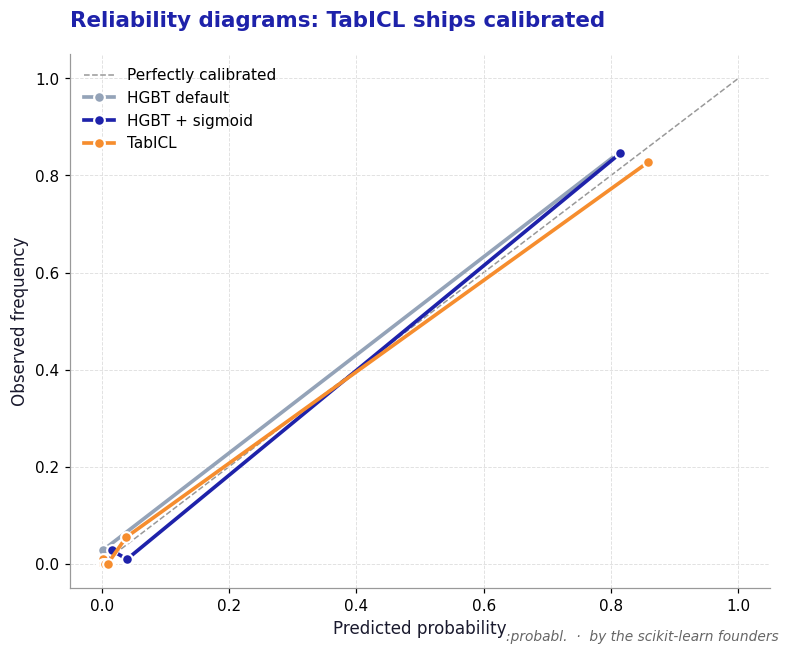


Expected Calibration Error (lower is better):


,ECE
model,
HGBT default,0.0079
HGBT + sigmoid,0.0116
TabICL,0.0074


In [5]:
from sklearn.calibration import calibration_curve

def ece(y_true, y_prob, n_bins=10):
    """Expected Calibration Error using quantile bins."""
    bins = np.quantile(y_prob, np.linspace(0, 1, n_bins + 1))
    bins[0], bins[-1] = 0.0, 1.0 + 1e-9
    err = 0.0
    n = len(y_prob)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        err += (mask.sum() / n) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return err

fig, ax = plt.subplots(figsize=(7.2, 6.0))
ax.plot([0, 1], [0, 1], "--", color="#999999", linewidth=1.0, label="Perfectly calibrated", zorder=1)

ece_rows = []
y_test_arr = y_test.to_numpy()
for name, info in results.items():
    p = info["est"].predict_proba(X_test)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test_arr, p, n_bins=10, strategy="quantile")
    ax.plot(
        prob_pred, prob_true,
        marker="o", color=info["color"], linewidth=2.4, markersize=7,
        markeredgecolor="white", markeredgewidth=1.4,
        label=name, zorder=3,
    )
    ece_rows.append({"model": name, "ECE": ece(y_test_arr, p, n_bins=10)})

ax.set_xlabel("Predicted probability", color=DARK, fontsize=11)
ax.set_ylabel("Observed frequency", color=DARK, fontsize=11)
ax.set_title(
    "Reliability diagrams: TabICL ships calibrated",
    color=BLUE, fontsize=14, fontweight="bold", loc="left", pad=18,
)
ax.grid(True, color="#E0E0E0", linestyle="--", linewidth=0.6, zorder=0)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["bottom", "left"]:
    ax.spines[spine].set_color("#999999")
ax.legend(loc="upper left", frameon=False)
fig.text(0.99, 0.02, ":probabl.  ·  by the scikit-learn founders",
         ha="right", color="#666666", fontsize=9, style="italic")
plt.tight_layout()

import os
os.makedirs("../recordings/final", exist_ok=True)
plt.savefig("../recordings/final/demo3_chart.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

ece_df = pd.DataFrame(ece_rows).set_index("model").round(4)
print("\nExpected Calibration Error (lower is better):")
display(ece_df)

In [ ]:
import os
from pathlib import Path

# Load SKORE_HUB_API_KEY from .env at the repo root (one level up from /demos)
_env_path = Path("..") / ".env"
if _env_path.exists():
    for _line in _env_path.read_text().splitlines():
        _line = _line.strip()
        if not _line or _line.startswith("#") or "=" not in _line:
            continue
        _k, _v = _line.split("=", 1)
        os.environ.setdefault(_k.strip(), _v.strip())

skore.login()

# Discover the workspace owned by this API key
from httpx import Client
from skore_hub_project.authentication.uri import URI
with Client(base_url=str(URI()),
            headers={"X-API-Key": os.environ["SKORE_HUB_API_KEY"]},
            timeout=20.0, follow_redirects=True) as _c:
    _me = _c.get("/identity/users/me").json()
_workspace = next(pid for (pid, role) in _me.get("workspaces", {}).values() if role == "owner")

project_name = f"{_workspace}/demo3-calibrated-probabilities"
project = skore.Project(project_name, mode="hub")

# Skore Hub stores per-estimator reports; the comparison view is reconstructed
# from the three reports sharing the same project.
for _name, _report in reports.items():
    project.put(f"calibration-{_name.lower().replace(' + ', '-').replace(' ', '-')}", _report)

hub_url = f"https://skore.probabl.ai/projects/{project_name}"
print(f"Pushed three reports to Skore Hub project: {project_name}")
print(f"URL: {hub_url}")
print(f"https://skore.probabl.ai/{project.name}")


╭───────────────────────────────── Login to Skore Hub ─────────────────────────────────╮
│                                                                                      │
│                        Successfully logged in, using API key.                        │
│                                                                                      │
╰──────────────────────────────────────────────────────────────────────────────────────╯

Output()

Consult your report at 
]8;id=11864978;https://skore.probabl.ai/debray.yann/demo3-calibrated-probabilities/estimators/8780\https://skore.probabl.ai/debray.yann/demo3-calibrated-probabilities/estimators/8780]8;;\

Output()

Consult your report at 
]8;id=11864981;https://skore.probabl.ai/debray.yann/demo3-calibrated-probabilities/estimators/8781\https://skore.probabl.ai/debray.yann/demo3-calibrated-probabilities/estimators/8781]8;;\

Output()